In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np

# Reading the cleaned dataset
url = r"/home/youssef/Desktop/Data_Projects/Egypt_Education/Data/education_cleaned.csv"
df = pd.read_csv(url)
df_ml = df.copy()
df_ml.head()

,Student_Name,Student_Age,Student_Year,Father_Degree,Mother_Degree,Education_Type,Subject_1,Subject_2,Subject_3,Subject_4,Subject_5,Subject_6,Subject_7,Subject_8,Subject_9,Subject_10,Total_Score,Average_Score,Performance,Student_Year_num
0,Allison Lang,18,9,High School,High School,IB,72.236740,85.931149,65.698513,84.163844,78.179414,50.578209,70.071681,80.294509,72.709741,59.080678,718.944478,71.894448,Good,9
1,Jaclyn Mcneil,14,9,Bachelor,PhD,IB,91.603078,73.186427,64.240239,47.786542,83.138581,66.913702,42.587211,87.997009,89.176862,78.493158,725.122809,72.512281,Good,9
2,Melissa Lee,16,10,Unknown,PhD,IB,100.000000,83.985923,89.378162,82.446853,86.368818,90.347020,100.000000,83.972296,69.212961,79.206634,864.918668,86.491867,Excellent,10
3,Timothy Maxwell,14,10,Bachelor,Bachelor,Thanweya,91.082131,100.000000,78.802220,78.447670,64.606239,82.045421,69.869099,91.122870,95.207752,52.602706,803.786108,80.378611,Good,10
4,Eric Steele,17,11,PhD,Unknown,IGCSE,74.906144,69.518146,65.284841,56.317028,69.758140,85.810641,63.776955,61.802599,84.951132,68.146467,700.272092,70.027209,Good,11


In [2]:
# Creating age groups based on Student_Age
df_ml["Age_Group"] = pd.cut(
    df_ml["Student_Age"],
    bins=[13, 15, 17, 19],
    labels=["14-15", "16-17", "18-19"]
)

In [3]:
# Mapping education levels to numeric values for both parents
edu_map = {
    "Unknown": 1,
    "High School": 2,
    "Bachelor": 3,
    "Master": 4,
    "PhD": 5
}

df_ml["Father_Edu_Num"] = df_ml["Father_Degree"].map(edu_map)
df_ml["Mother_Edu_Num"] = df_ml["Mother_Degree"].map(edu_map)

df_ml["Parent_Edu_Gap"] = abs(df_ml["Father_Edu_Num"] - df_ml["Mother_Edu_Num"])

In [4]:
# Creating a new feature for average score across all subjects
subject_cols = [col for col in df_ml.columns if "Subject_" in col]
df_ml["Subject_Avg"] = df_ml[subject_cols].mean(axis=1)

In [5]:
# One-hot encoding for categorical variables
categorical_cols = ["Father_Degree", "Mother_Degree", "Education_Type", "Student_Year", "Age_Group"]
df_ml = pd.get_dummies(df_ml, columns=categorical_cols, drop_first=True)

In [6]:
# Dropping unnecessary columns
df_ml.drop(columns=["Student_Name"], inplace=True)
df_ml.drop(columns=["Father_Degree", "Mother_Degree"], errors="ignore", inplace=True)

In [7]:
# Preparing features and target variable
subject_cols = [col for col in df_ml.columns if "Subject_" in col]
X = df_ml.drop(columns=[
    "Average_Score",
    "Total_Score",
    "Subject_Avg",
    "Performance",
    "Student_Name"
] + subject_cols, errors="ignore")

y = df_ml["Average_Score"]

# Convert all columns to numeric (especially bool → int)
X = X.astype(int)

In [8]:
df_ml.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Student_Age                50000 non-null  int64  
 1   Subject_1                  50000 non-null  float64
 2   Subject_2                  50000 non-null  float64
 3   Subject_3                  50000 non-null  float64
 4   Subject_4                  50000 non-null  float64
 5   Subject_5                  50000 non-null  float64
 6   Subject_6                  50000 non-null  float64
 7   Subject_7                  50000 non-null  float64
 8   Subject_8                  50000 non-null  float64
 9   Subject_9                  50000 non-null  float64
 10  Subject_10                 50000 non-null  float64
 11  Total_Score                50000 non-null  float64
 12  Average_Score              50000 non-null  float64
 13  Performance                50000 non-null  str    
 14  S

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
# Importing regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Creating a dictionary of models to evaluate
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor()
}

In [11]:
# Evaluating models
from sklearn.metrics import r2_score, mean_squared_error
results = []

# Training and evaluating each model
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    results.append({
        "Model": name,
        "R2": r2_score(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds))
    })

# Displaying results
results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)
print(results_df)

               Model        R2      RMSE
2              Lasso -0.000214  4.528461
1              Ridge -0.000319  4.528698
0             Linear -0.000320  4.528699
5  Gradient Boosting -0.001087  4.530436
3      Decision Tree -0.037538  4.612178
4      Random Forest -0.038367  4.614020


In [12]:
# Cross-validation for the best model
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring="r2")
print(scores.mean())

-0.00214895477617878


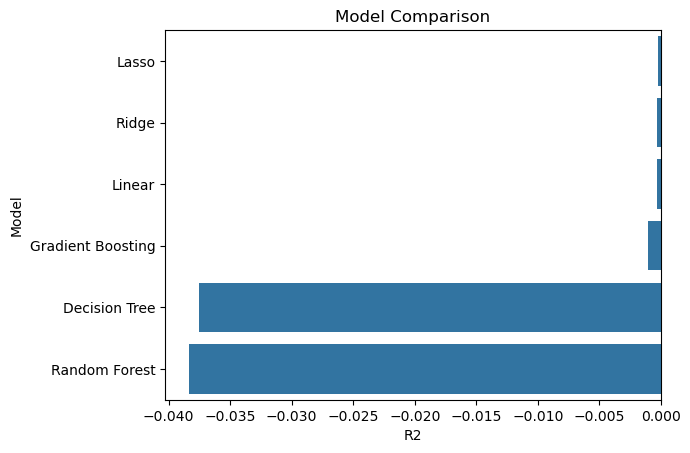

In [13]:
# Visualizing model performance

import seaborn as sns
import matplotlib.pyplot as plt

# Bar plot for R2 scores
sns.barplot(x="R2", y="Model", data=results_df)
plt.title("Model Comparison")
plt.show()

In [21]:
# Classification pipeline (if we want to predict Performance category instead of Average_Score)
X = df_ml.drop(columns=[
    "Performance",
    "Average_Score",
    "Total_Score",
    "Subject_1",
    "Subject_2",
    "Subject_3",
    "Subject_4",
    "Subject_5",
    "Subject_6",
    "Subject_7",
    "Subject_8",
    "Subject_9",
    "Subject_10"
], errors="ignore")

y = df_ml["Performance"]

In [22]:
# Encoding target variable for classification
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [23]:
# Splitting data into training and testing sets for classification
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
# Importing classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score

# Creating a dictionary of classification models to evaluate
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "Gradient Boosting": GradientBoostingClassifier()
}

In [25]:
# Evaluating classification models
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "F1 Score": f1_score(y_test, preds, average="weighted")
    })

import pandas as pd
results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False)
print(results_df)

/home/youssef/miniforge3/envs/data_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                 Model  Accuracy  F1 Score
1        Decision Tree    1.0000  1.000000
3    Gradient Boosting    1.0000  1.000000
2        Random Forest    0.9993  0.999288
0  Logistic Regression    0.9798  0.978750
